In [2]:
import os

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_5d56c35624f62448be951106932441e1'

!pip install -q kaggle
!kaggle datasets download -d imakash3011/customer-personality-analysis
!unzip -o customer-personality-analysis.zip

Dataset URL: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis
License(s): CC0-1.0
100% 62.0k/62.0k [00:00<00:00, 1.16MB/s]

Archive:  customer-personality-analysis.zip
  inflating: marketing_campaign.csv  


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('marketing_campaign.csv', sep='\t')
print(df.shape)
print(df.columns.tolist())
df.head()

(2240, 29)
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df['Age'] = 2026 - df['Year_Birth']

df = df.drop(columns=['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'], errors='ignore')

print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

df['Income'] = df['Income'].fillna(df['Income'].median())

print(df.shape)

Missing values:
 Income    24
dtype: int64
(2240, 25)


In [5]:
df = pd.get_dummies(df, columns=['Education', 'Marital_Status'], drop_first=True)

print(df['Age'].describe())
print(df['Income'].describe())

df = df[(df['Age'] < 100) & (df['Income'] < 200000)]
print(df.shape)

count    2240.000000
mean       57.194196
std        11.984069
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64
count      2240.000000
mean      52237.975446
std       25037.955891
min        1730.000000
25%       35538.750000
50%       51381.500000
75%       68289.750000
max      666666.000000
Name: Income, dtype: float64
(2236, 34)


In [6]:
from sklearn.preprocessing import StandardScaler

X = df.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(2236, 34)


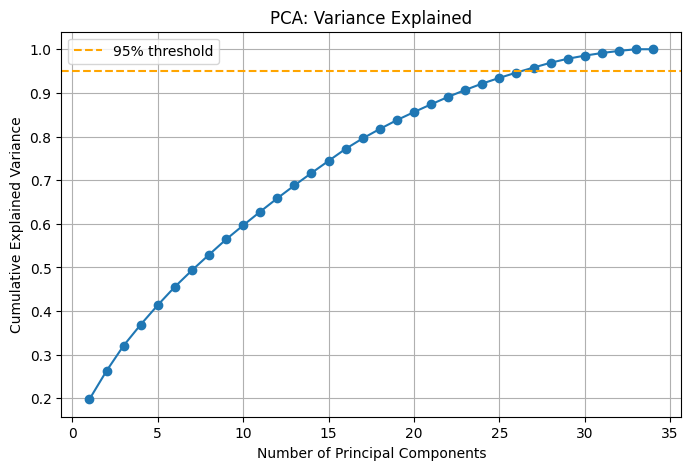

Components needed for 95% variance: 27


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_full = PCA().fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Variance Explained')
plt.legend()
plt.grid(True)
plt.show()

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

In [8]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)
print("Variance explained by 3 components:", pca.explained_variance_ratio_.sum())

Shape after PCA: (2236, 3)
Variance explained by 3 components: 0.32083812028760655


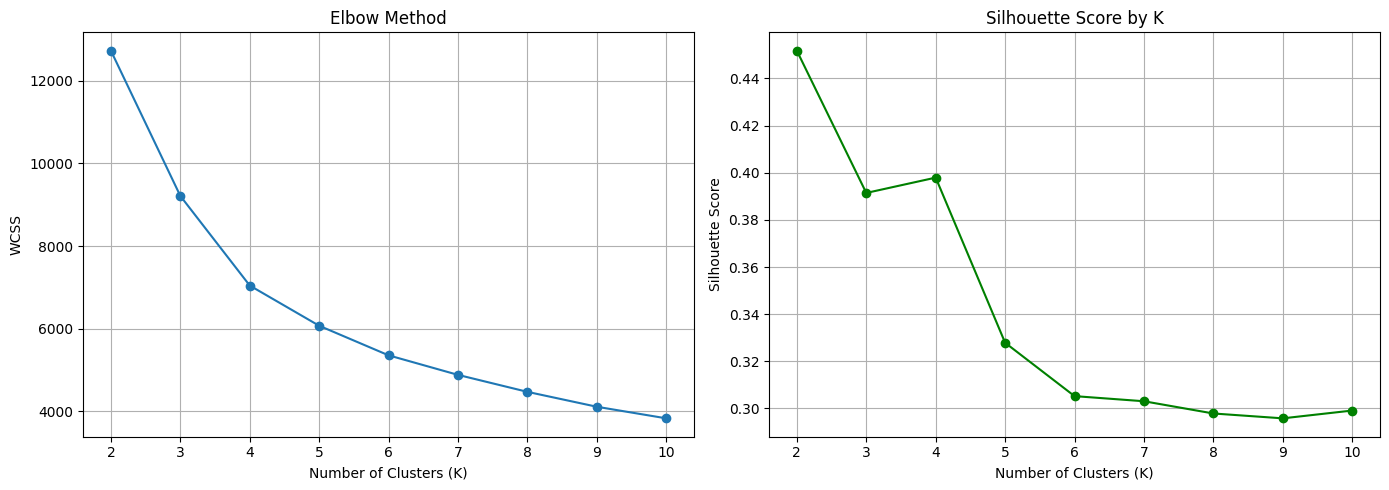

K=2: Silhouette Score = 0.4518
K=3: Silhouette Score = 0.3914
K=4: Silhouette Score = 0.3979
K=5: Silhouette Score = 0.3279
K=6: Silhouette Score = 0.3052
K=7: Silhouette Score = 0.3030
K=8: Silhouette Score = 0.2979
K=9: Silhouette Score = 0.2958
K=10: Silhouette Score = 0.2991


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, wcss, marker='o')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS')
axes[0].set_title('Elbow Method')
axes[0].grid(True)

axes[1].plot(K_range, silhouette_scores, marker='o', color='green')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].grid(True)

plt.tight_layout()
plt.show()

for k, s in zip(K_range, silhouette_scores):
    print(f"K={k}: Silhouette Score = {s:.4f}")

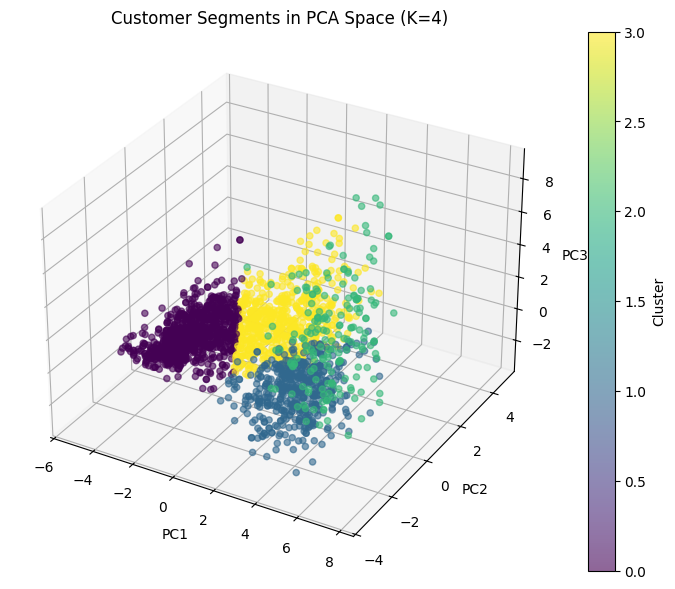

Cluster
0    966
1    485
2    180
3    605
Name: count, dtype: int64


In [10]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

df['Cluster'] = cluster_labels

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=cluster_labels, cmap='viridis', alpha=0.6)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title(f'Customer Segments in PCA Space (K={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.show()

print(df['Cluster'].value_counts().sort_index())

In [11]:
persona_summary = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Income': 'mean',
    'MntWines': 'mean',
    'MntMeatProducts': 'mean',
    'NumWebPurchases': 'mean',
    'NumStorePurchases': 'mean',
    'NumWebVisitsMonth': 'mean',
    'Recency': 'mean'
}).round(1)

persona_summary['Count'] = df['Cluster'].value_counts().sort_index()
print(persona_summary)

          Age   Income  MntWines  MntMeatProducts  NumWebPurchases  \
Cluster                                                              
0        53.2  33688.6      37.0             22.9              2.1   
1        57.9  72011.9     481.7            404.0              5.3   
2        55.9  80723.7     876.6            483.8              5.6   
3        63.0  56474.0     418.1            112.8              5.8   

         NumStorePurchases  NumWebVisitsMonth  Recency  Count  
Cluster                                                        
0                      3.1                6.6     49.0    966  
1                      8.6                3.1     51.4    485  
2                      8.1                3.2     46.1    180  
3                      7.1                5.7     48.3    605  


## Customer Segmentation: Strategic Persona Matrix

Our K-Means clustering (K=4, validated via Elbow Method and Silhouette Score)
revealed four distinct customer segments, each requiring a different business strategy.

### Cluster 0: "Budget-Conscious Browsers" (966 customers — largest segment)
- Profile: Age 53, Income ₹33.7k, lowest spend across every product category,
  but the highest web visit frequency of any segment.
- Insight: This group browses frequently but converts rarely.
- Action: Retarget with discount campaigns, flash sales, and low-cost entry products.

### Cluster 1: "Affluent Loyalists" (485 customers)
- Profile: Age 58, Income ₹72k, high spend on wine and meat products,
  strongly prefers in-store purchases over web.
- Insight: High-value customers who trust in-person shopping over digital channels.
- Action: Loyalty programs, in-store exclusive events, personalized offline outreach.

### Cluster 2: "Premium VIPs" (180 customers — smallest, highest-value segment)
- Profile: Age 56, Income ₹80.7k (highest), highest spend on wine and meat products.
- Insight: A small but disproportionately valuable segment.
- Action: White-glove service, early access to new products, premium membership tier.

### Cluster 3: "Mature Value Seekers" (605 customers)
- Profile: Age 63 (oldest), Income ₹56.5k, moderate spend and web engagement.
- Insight: Steady, consistent customers without over-indexing on one channel.
- Action: Simple, trustworthy web experience with clear value messaging.

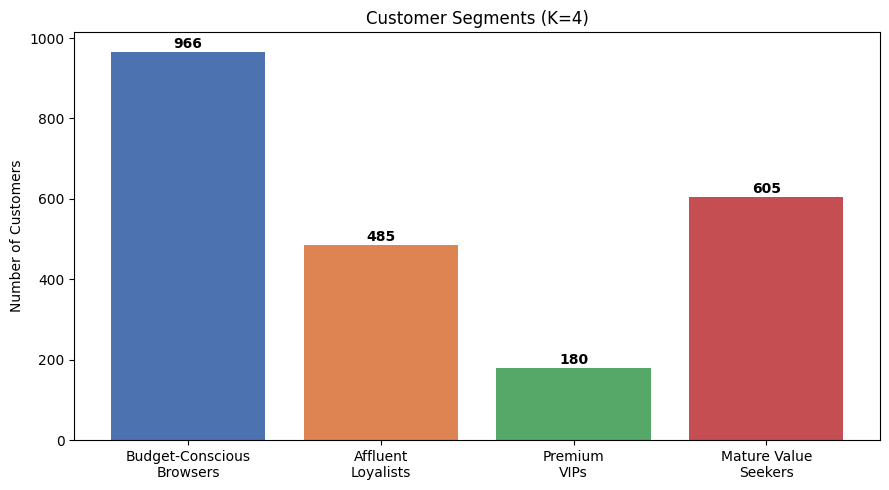

In [12]:
import matplotlib.pyplot as plt

persona_names = {
    0: 'Budget-Conscious\nBrowsers',
    1: 'Affluent\nLoyalists',
    2: 'Premium\nVIPs',
    3: 'Mature Value\nSeekers'
}

fig, ax = plt.subplots(figsize=(9, 5))
counts = df['Cluster'].value_counts().sort_index()
labels = [persona_names[i] for i in counts.index]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

bars = ax.bar(labels, counts.values, color=colors)
ax.set_ylabel('Number of Customers')
ax.set_title('Customer Segments (K=4)')
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, count + 10, str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusion

Translating unlabeled transactional data into these four personas shows that
customer value doesn't correlate directly with engagement frequency — Cluster 0
visits most often but spends least, while Cluster 2 is nearly invisible in web
activity but drives the highest per-customer revenue. This is exactly the kind
of counter-intuitive, actionable insight unsupervised learning is meant to surface.